In [1]:
import urllib.request

url = "https://maxi.riken.jp/star_data/J1612-524/J1612-524_g_lc_1day_all.dat"
fname = "J1612-524_g_lc_1day_all.dat"

urllib.request.urlretrieve(url, fname)

('J1612-524_g_lc_1day_all.dat', <http.client.HTTPMessage at 0x10cd0e350>)

In [5]:
import pandas as pd

cols = [
    "mjd",
    "flux_2_20", "err_2_20",
    "flux_2_4", "err_2_4",
    "flux_4_10", "err_4_10",
    "flux_10_20", "err_10_20",
]

df = pd.read_csv(fname, sep=r"\s+", names=cols)
print(df.shape)
df.head()

(5146, 9)


,mjd,flux_2_20,err_2_20,flux_2_4,err_2_4,flux_4_10,err_4_10,flux_10_20,err_10_20
0,55053.5,0.108890,0.082890,0.074699,0.054621,0.029035,0.036475,0.011473,0.045402
1,55054.5,0.231242,0.027672,0.104946,0.016991,0.075329,0.012614,0.044073,0.015052
2,55055.5,0.168920,0.019135,0.083585,0.011879,0.057979,0.008962,0.024726,0.009989
3,55056.5,0.127611,0.013072,0.072002,0.008256,0.041419,0.006041,0.015974,0.007119
4,55057.5,0.135478,0.009858,0.077589,0.005778,0.045598,0.004439,0.012955,0.005717


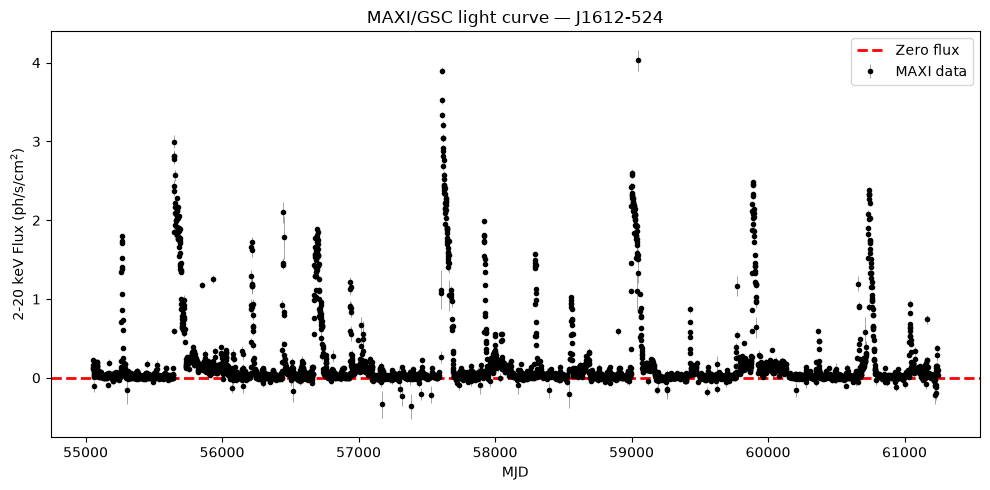

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    df["mjd"], df["flux_2_20"], yerr=df["err_2_20"],
    fmt="o", ms=3, elinewidth=0.5, capsize=0, color="k", ecolor="gray", label="MAXI data"
)

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC light curve — J1612-524")
ax.axhline(0, color="red", lw=2, ls="--", label="Zero flux")
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
#lc clean

In [8]:
import numpy as np

# keep only positive, reasonably significant points
sig = df["flux_2_20"] / df["err_2_20"].replace(0, np.nan)
mask = (df["flux_2_20"] > 0) & (sig > 2)  # >2 sigma detections only

clean = df[mask].sort_values("mjd").reset_index(drop=True)
print(f"{len(clean)} / {len(df)} points kept")

2896 / 5146 points kept


In [9]:
from scipy.signal import find_peaks

x = clean["mjd"].values
y = clean["flux_2_20"].values

# prominence: peak must stand out from local baseline by at least this much
# distance: minimum separation (in samples) between peaks, to avoid double-counting one outburst
peaks, props = find_peaks(
    y,
    prominence=0.3,  
    distance=20        # in samples, not necessarily means days.. we will explore this further below.
)

peak_mjd = x[peaks]
peak_flux = y[peaks]
peak_prom = props["prominences"]

# for m, f, p in zip(peak_mjd, peak_flux, peak_prom):
#     print(f"MJD {m:.1f}   flux={f:.2f}   prominence={p:.2f}")

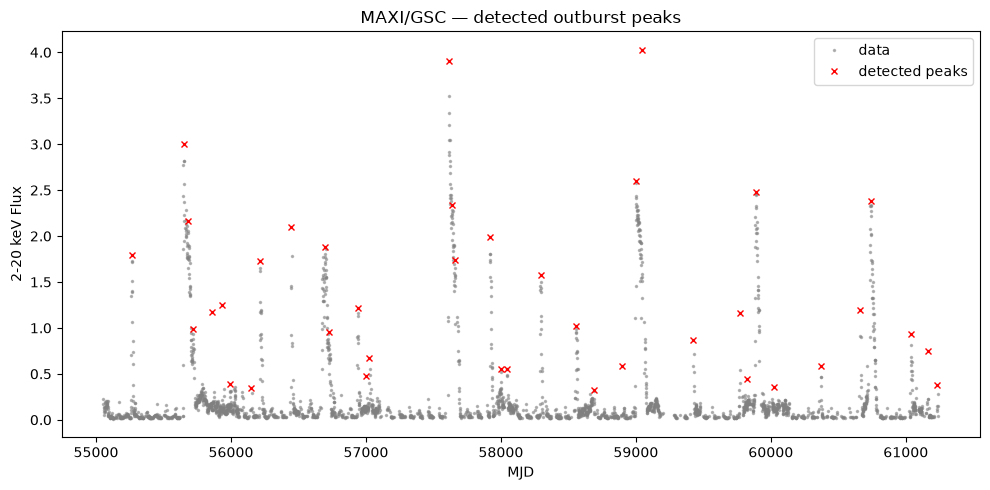

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, ".", color="gray", ms=3, alpha=0.5, label="data")
ax.plot(peak_mjd, peak_flux, "rx", ms=5, label="detected peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux")
ax.set_title("MAXI/GSC — detected outburst peaks")
ax.legend()
plt.tight_layout()
plt.show()

# as discussed in our meetings, this is not yeilding good detections... probably because data sampling is not right, lets try and fix that

In [13]:
import numpy as np

# use median + MAD (median absolute deviation) — robust to outliers/outbursts
baseline = np.median(flux_smooth)
mad = np.median(np.abs(flux_smooth - baseline))
sigma_robust = 1.4826 * mad   # converts MAD to a "sigma"-like scale

print(f"baseline={baseline:.3f}, robust sigma={sigma_robust:.3f}")

NameError: name 'flux_smooth' is not defined

In [25]:
from scipy.signal import find_peaks

n_sigma_height = 7     # peak must be 5 robust-sigma above baseline
n_sigma_prom   = 5       # and stand out from local surroundings by same amount

peaks, props = find_peaks(
    flux_smooth,
    height=baseline + n_sigma_height * sigma_robust,
    prominence=n_sigma_prom * sigma_robust,
    distance=100   # this one is still physically motivated (expected outburst spacing), not noise-derived
)

peak_mjd = mjd_grid[peaks]
peak_flux = flux_smooth[peaks]

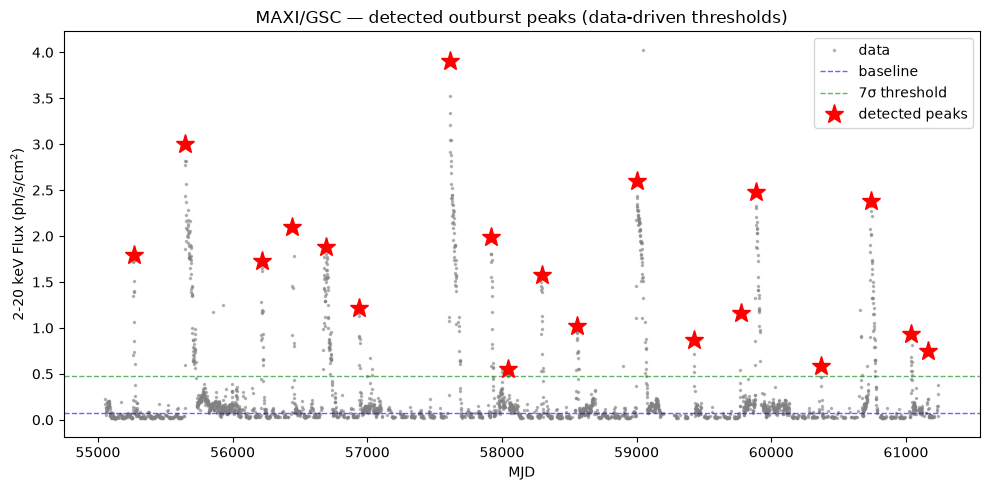

Found 19 outburst peaks:
  MJD 55265.5   flux=1.80
  MJD 55649.5   flux=3.00
  MJD 56216.5   flux=1.73
  MJD 56444.5   flux=2.10
  MJD 56696.5   flux=1.89
  MJD 56940.5   flux=1.21
  MJD 57612.5   flux=3.90
  MJD 57919.5   flux=1.99
  MJD 58046.5   flux=0.55
  MJD 58294.5   flux=1.57
  MJD 58555.5   flux=1.02
  MJD 59000.5   flux=2.60
  MJD 59425.5   flux=0.87
  MJD 59771.5   flux=1.17
  MJD 59888.5   flux=2.48
  MJD 60369.5   flux=0.59
  MJD 60739.5   flux=2.38
  MJD 61038.5   flux=0.93
  MJD 61162.5   flux=0.74


In [26]:
import matplotlib.pyplot as plt

# snap each smoothed-peak MJD to the true max raw flux within +/-15 days
refined_mjd, refined_flux = [], []
for m in peak_mjd:
    window = clean[(clean["mjd"] > m - 15) & (clean["mjd"] < m + 15)]
    if len(window):
        idx = window["flux_2_20"].idxmax()
        refined_mjd.append(clean.loc[idx, "mjd"])
        refined_flux.append(clean.loc[idx, "flux_2_20"])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(baseline + n_sigma_height * sigma_robust, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma_height}σ threshold")
ax.plot(refined_mjd, refined_flux, "r*", ms=14, label="detected peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — detected outburst peaks (data-driven thresholds)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(refined_mjd)} outburst peaks:")
for m, f in zip(refined_mjd, refined_flux):
    print(f"  MJD {m:.1f}   flux={f:.2f}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d, label

# data cleaninf.... get rid of negative fluxes and low-significance points and sort it by mjd.
sig = df["flux_2_20"] / df["err_2_20"].replace(0, np.nan)
mask = (df["flux_2_20"] > 0) & (sig > 2)
clean = df[mask].sort_values("mjd").reset_index(drop=True)

# the data is probably not exactly samplted at 1 day, even though the data says it is.. we can check that 
mjd_grid = np.arange(clean["mjd"].min(), clean["mjd"].max() + 1, 1.0)
flux_grid = np.interp(mjd_grid, clean["mjd"].values, clean["flux_2_20"].values)
flux_smooth = uniform_filter1d(flux_grid, size=5)

delta_t_before, delta_t_after = np.diff(clean["mjd"]), np.diff(mjd_grid)
print(f"Median delta_t (before): {np.mean(delta_t_before):.3f} days")
print(f"Median delta_t (after): {np.mean(delta_t_after):.3f} days")

Median delta_t (before): 2.137 days
Median delta_t (after): 1.000 days


In [35]:
#notice that I am taking the mean here...not the median.. np.diff will give me all the delta t values... median would afcourse be 1, as in most of the cases, the data is recorded every one day. However, mean will give me the average delta t, which is more useful in this case, as it will give me an idea of how much the data is sampled on average. If the mean is significantly greater than 1, it means that there are gaps in the data, which can affect the peak finding algorithm (as we are using the width/distance parameter in find_peaks). Once we have interpolated the data to a uniform grid, we can use the mean delta t to set the distance parameter in find_peaks, which will help us avoid detecting multiple peaks for a single outburst. See how the mean delta t after the interpolations sits at 1.00 which is great for us!! 

In [ ]:
## AI (claude) suggested the below approach which is a neat trick.. I will annotate the code to explain the things.

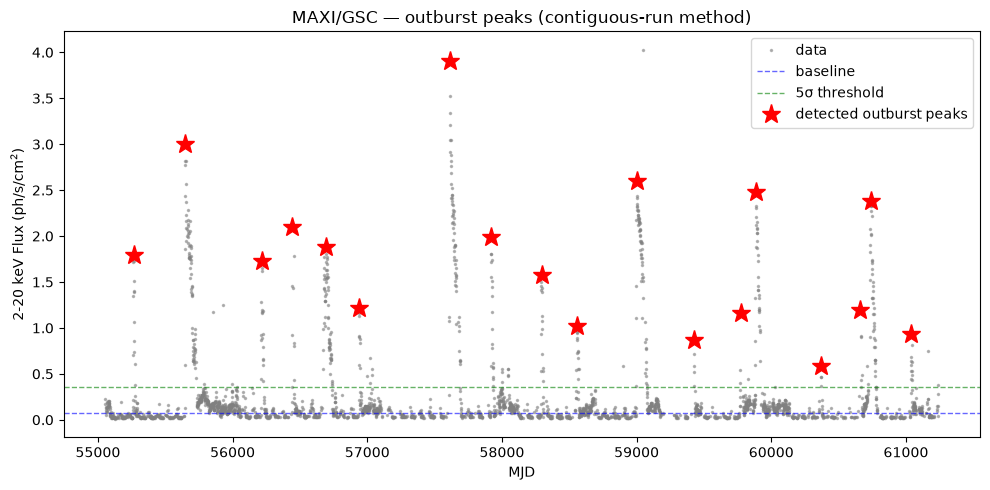

Found 18 outburst peaks:
  MJD 55265.5   flux=1.80
  MJD 55649.5   flux=3.00
  MJD 56216.5   flux=1.73
  MJD 56444.5   flux=2.10
  MJD 56696.5   flux=1.89
  MJD 56940.5   flux=1.21
  MJD 57612.5   flux=3.90
  MJD 57919.5   flux=1.99
  MJD 58294.5   flux=1.57
  MJD 58555.5   flux=1.02
  MJD 59000.5   flux=2.60
  MJD 59425.5   flux=0.87
  MJD 59771.5   flux=1.17
  MJD 59888.5   flux=2.48
  MJD 60369.5   flux=0.59
  MJD 60660.5   flux=1.20
  MJD 60739.5   flux=2.38
  MJD 61038.5   flux=0.93


In [ ]:
#first lets establish a baseline level of the counts. i.e the median
baseline = np.median(flux_smooth)

# lets calculate the MAD (median absolute deviation) which is a robust measure of variability. It is less sensitive to outliers than the standard deviation. We will use this to define a threshold for detecting "active" periods in the light curve.
mad = np.median(np.abs(flux_smooth - baseline))

# this is the trick... MAD is not exactly eqvivalent to standard deviation, but it can be converted to a "sigma"-like scale by multiplying by 1.4826. The number comes for the fact that, 1 MAD ~ 0.6745 sigma.. so 1 sigma ~ 1/0.6745 = 1.4826 MAD.
sigma_robust = 1.4826 * mad

# lets define a 5 sigma threshold. 
n_sigma = 5
threshold = baseline + n_sigma * sigma_robust

# -------- 4. label contiguous "active" (above-threshold) stretches --------
active = flux_smooth > threshold
labels, n_groups = label(active)

min_run_days = 10   # require a stretch to last at least this long -> rejects 1-day noise spikes

peak_mjd, peak_flux = [], []
for g in range(1, n_groups + 1):
    idx = np.where(labels == g)[0]
    if len(idx) < min_run_days:
        continue
    # peak = max smoothed flux within this stretch
    i_max = idx[np.argmax(flux_smooth[idx])]
    m = mjd_grid[i_max]

    # snap to the true max in the raw (unsmoothed) data nearby
    window = clean[(clean["mjd"] > m - 15) & (clean["mjd"] < m + 15)]
    if len(window):
        j = window["flux_2_20"].idxmax()
        peak_mjd.append(clean.loc[j, "mjd"])
        peak_flux.append(clean.loc[j, "flux_2_20"])

# -------- 5. plot --------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(clean["mjd"], clean["flux_2_20"], ".", color="gray", ms=3, alpha=0.5, label="data")
ax.axhline(baseline, color="blue", lw=1, ls="--", alpha=0.6, label="baseline")
ax.axhline(threshold, color="green", lw=1, ls="--", alpha=0.6, label=f"{n_sigma}σ threshold")
ax.plot(peak_mjd, peak_flux, "r*", ms=14, label="detected outburst peaks")

ax.set_xlabel("MJD")
ax.set_ylabel("2-20 keV Flux (ph/s/cm$^2$)")
ax.set_title("MAXI/GSC — outburst peaks (contiguous-run method)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(peak_mjd)} outburst peaks:")
for m, f in zip(peak_mjd, peak_flux):
    print(f"  MJD {m:.1f}   flux={f:.2f}")